In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
import pandas_ta
import talib

# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *


import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline

In [31]:

asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
data = load_candles('binance',asset, quote, timeframe)['2022':'2025']#.iloc[-35000:-5000]
# data = data.sample(n=5000,replace=True).reset_index(drop=True)
# .assign(log_price=lambda df:df['close'].apply(np.log)
# ).assign(log_rets=lambda df:df.log_price.diff())
nhours = 7; train_ratio = 1;  long_short = 'long'
btargs = {'transaction_cost':0.001, 'slippage':0.003, 'precision':3, 'period_costs':0}

# data = data.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})

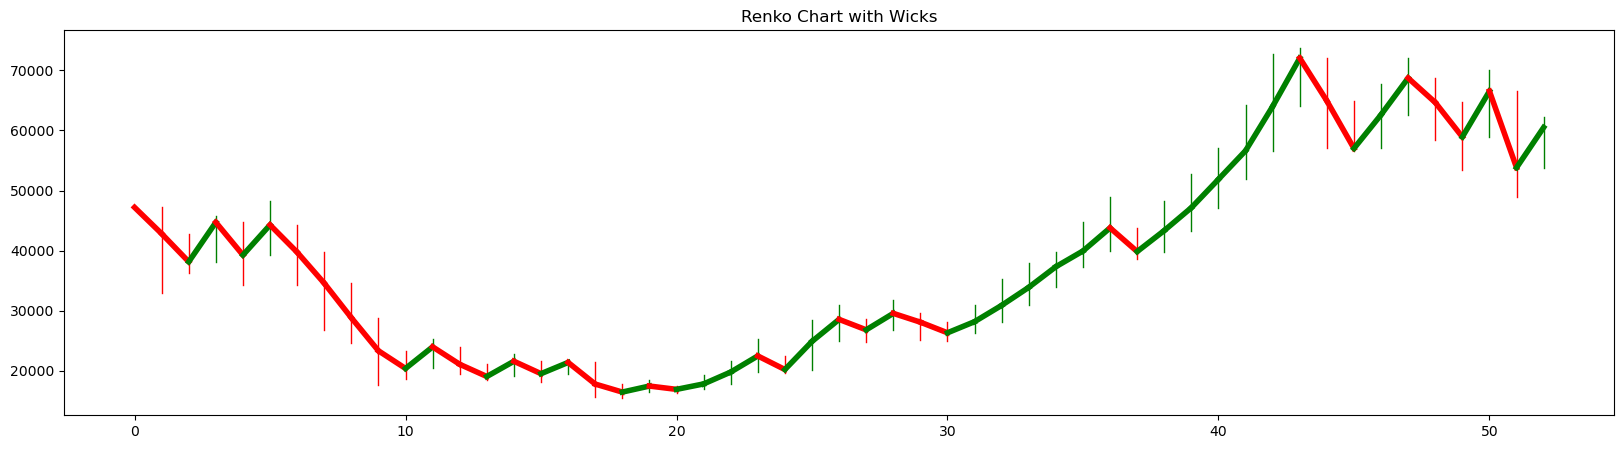

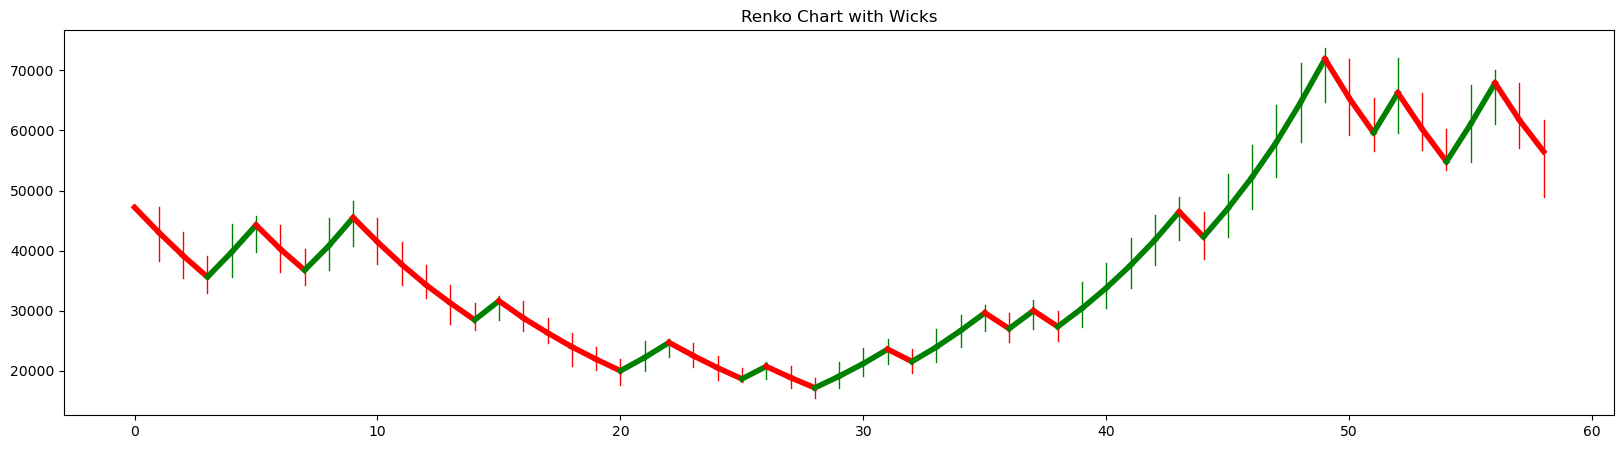

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_atr(data, period=14):
    high_low = data['high'] - data['low']
    high_close = np.abs(data['high'] - data['close'].shift())
    low_close = np.abs(data['low'] - data['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    atr = true_range.rolling(window=period, min_periods=1).mean()
    return atr

def calculate_renko(data, method='atr', atr_period=14, percent=2.0, multiplier=1):
    if method == 'atr':
        brick_size = calculate_atr(data, atr_period) * multiplier
    elif method == 'percent':
        brick_size = data['close'] * (percent / 100.0) * multiplier
    else:
        raise ValueError("Method must be 'atr' or 'percent'")

    renko_price = []
    renko_direction = []
    wick_high = []
    wick_low = []

    prev_close = data['close'].iloc[0]
    renko_price.append(prev_close)
    renko_direction.append(0)  # Start with no direction
    wick_high.append(prev_close)
    wick_low.append(prev_close)

    for i in range(1, len(data)):
        movement = data['close'].iloc[i] - renko_price[-1]
        
        while abs(movement) >= brick_size.iloc[i]:
            if movement > 0:
                new_price = renko_price[-1] + brick_size.iloc[i]
                renko_price.append(new_price)
                renko_direction.append(1)
                wick_high.append(data['high'].iloc[i])
                wick_low.append(renko_price[-2])
            else:
                new_price = renko_price[-1] - brick_size.iloc[i]
                renko_price.append(new_price)
                renko_direction.append(-1)
                wick_high.append(renko_price[-2])
                wick_low.append(data['low'].iloc[i])
            movement = data['close'].iloc[i] - renko_price[-1]

        # Update the wicks for the current brick
        if renko_direction[-1] == 1:
            wick_high[-1] = max(wick_high[-1], data['high'].iloc[i])
            wick_low[-1] = renko_price[-2]
        elif renko_direction[-1] == -1:
            wick_low[-1] = min(wick_low[-1], data['low'].iloc[i])
            wick_high[-1] = renko_price[-2]

    renko_df = pd.DataFrame({
        'renko_price': renko_price,
        'renko_direction': renko_direction,
        'wick_high': wick_high,
        'wick_low': wick_low
    })
    return renko_df

def plot_renko(renko_df):
    plt.figure(figsize=(20, 5))
    
    for i in range(1, len(renko_df)):
        # Plot the brick body
        color = 'green' if renko_df['renko_direction'][i] == 1 else 'red'
        plt.plot([i-1, i], [renko_df['renko_price'][i-1], renko_df['renko_price'][i]], color=color, lw=4)

        # Plot the wicks
        plt.plot([i, i], [renko_df['wick_low'][i], renko_df['wick_high'][i]], color=color, lw=1)
    
    plt.title('Renko Chart with Wicks')
    plt.show()


# ATR-based Renko
renko_df_atr = calculate_renko(data, method='atr', atr_period=14, multiplier=3)
plot_renko(renko_df_atr)

# Percentage-based Renko
renko_df_percent = calculate_renko(data, method='percent', percent=2.0, multiplier=3)
plot_renko(renko_df_percent)


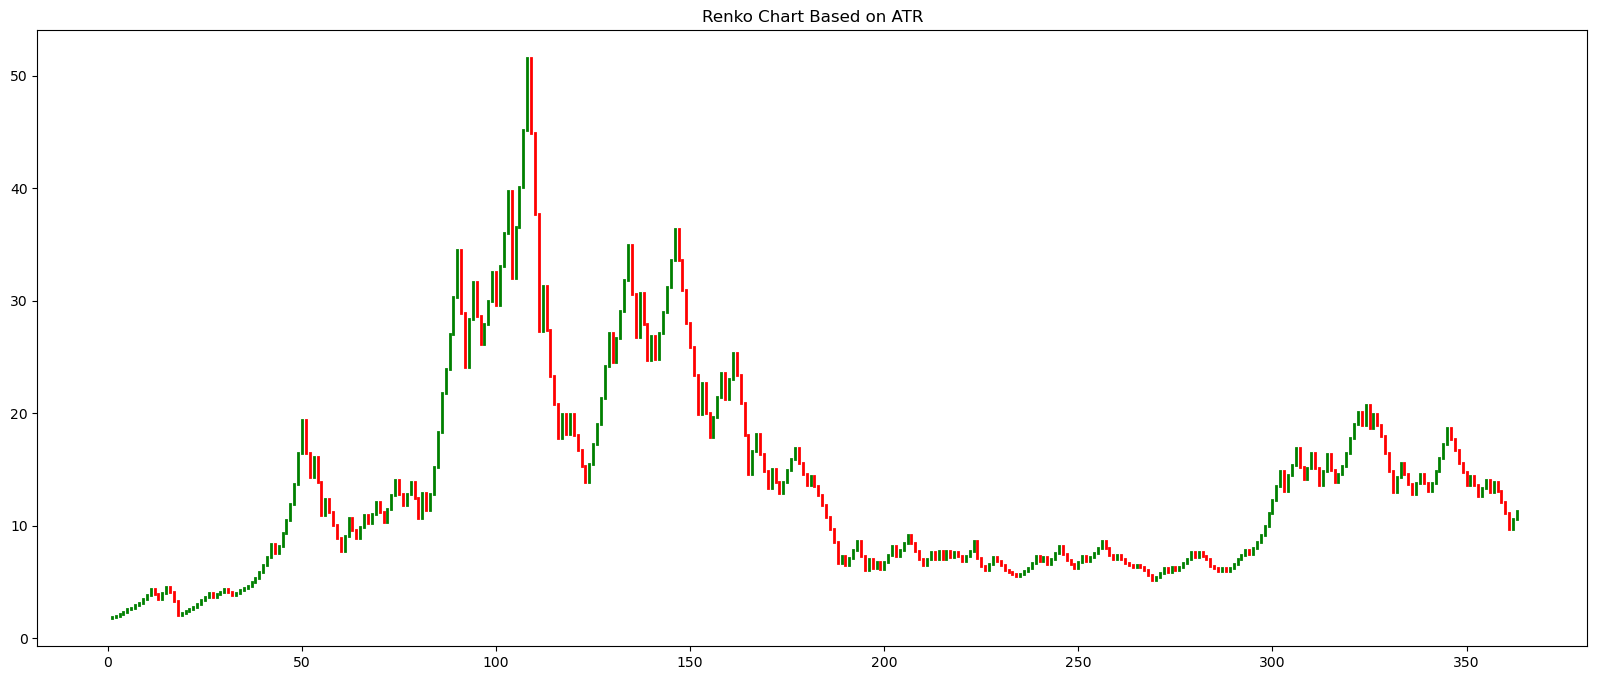

In [28]:
import matplotlib.pyplot as plt

def plot_renko(renko_df):
    plt.figure(figsize=(20, 8))
    
    for i in range(len(renko_df)):
        if i == 0:
            plt.plot([i, i], [renko_df['renko_price'][i], renko_df['renko_price'][i]], color='green' if renko_df['renko_direction'][i] == 1 else 'red', lw=2)
        else:
            if renko_df['renko_direction'][i] == 1:
                plt.plot([i, i], [renko_df['renko_price'][i-1], renko_df['renko_price'][i]], color='green', lw=2)
            else:
                plt.plot([i, i], [renko_df['renko_price'][i-1], renko_df['renko_price'][i]], color='red', lw=2)
    
    plt.title('Renko Chart Based on ATR')
    plt.show()

plot_renko(renko_df)
